<a href="https://colab.research.google.com/github/ali-yyyy/Deep-Learning-Lab/blob/main/2324111_Deep_Learning_Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ali Asghar
# 232411
# Deep Learning Lab 1

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
accuracy_score, confusion_matrix, classification_report,
mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.datasets import fetch_california_housing, load_iris, load_diabetes, load_breast_cancer
print("Environment ready.")

Environment ready.


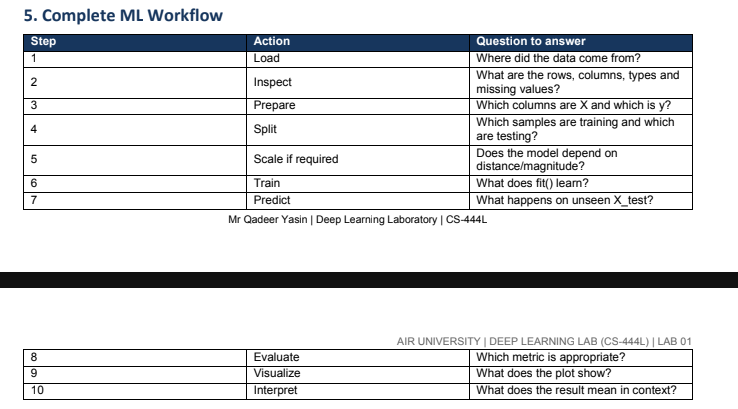

6.1 Load and Inspect the Dataset (1 + 2)

In [ ]:
wine_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"


wine_df = pd.read_csv(wine_url, sep=";")
display(wine_df.head())
print("Shape:", wine_df.shape)
print("\nData types:")
print(wine_df.dtypes)
print("\nMissing values:")
print(wine_df.isnull().sum())
print("\nSummary:")
display(wine_df.describe())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Shape: (1599, 12)

Data types:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Missing values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Summary:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


6.2 Visualize the Target

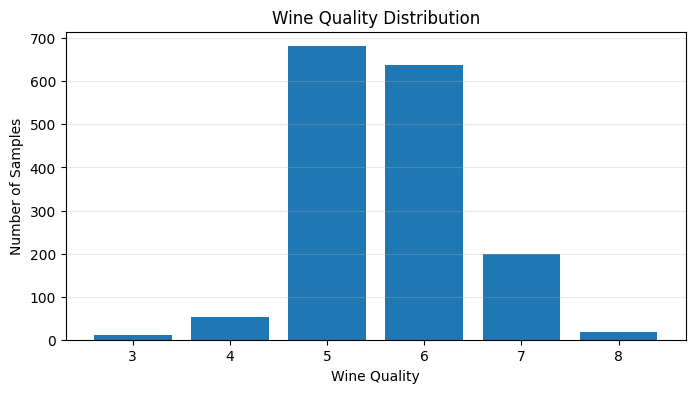

In [ ]:
quality_counts = wine_df["quality"].value_counts().sort_index()
plt.figure(figsize=(8,4))
plt.bar(quality_counts.index, quality_counts.values)
plt.xlabel("Wine Quality")
plt.ylabel("Number of Samples")
plt.title("Wine Quality Distribution")
plt.grid(axis="y", alpha=0.3)
plt.show()

Splitting Data

In [ ]:
X_wine = wine_df.drop(columns=["quality"])
y_wine = (wine_df["quality"] >= 6).astype(int)
X_train, X_test, y_train, y_test = train_test_split(
X_wine, y_wine,
test_size=0.20,
random_state=42,
stratify=y_wine
)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1279
Testing samples: 320


7.1 Baseline KNN Without Scaling

In [ ]:
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train, y_train)
y_pred_unscaled = knn_unscaled.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_unscaled))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_unscaled))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_unscaled))

Accuracy: 0.634375

Confusion Matrix:
[[104  45]
 [ 72  99]]

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.70      0.64       149
           1       0.69      0.58      0.63       171

    accuracy                           0.63       320
   macro avg       0.64      0.64      0.63       320
weighted avg       0.64      0.63      0.63       320



7.2 KNN With Feature Scaling


In [ ]:
scaler = StandardScaler()
# Learn scaling parameters from TRAINING data only
X_train_scaled = scaler.fit_transform(X_train)
# Apply the same parameters to TEST data
X_test_scaled = scaler.transform(X_test)
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = knn_scaled.predict(X_test_scaled)
print("Unscaled accuracy:", accuracy_score(y_test, y_pred_unscaled))
print("Scaled accuracy: ", accuracy_score(y_test, y_pred_scaled))
print("Accuracy:", accuracy_score(y_test, y_pred_scaled))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_scaled))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_scaled))

Unscaled accuracy: 0.634375
Scaled accuracy:  0.740625
Accuracy: 0.740625

Confusion Matrix:
[[108  41]
 [ 42 129]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.72      0.72       149
           1       0.76      0.75      0.76       171

    accuracy                           0.74       320
   macro avg       0.74      0.74      0.74       320
weighted avg       0.74      0.74      0.74       320



7.3 Experiment with K

,K,Accuracy
0,1,0.768750
1,2,0.712500
2,4,0.715625
3,8,0.753125
4,15,0.753125
5,12,0.753125


Best K on this test split: 1


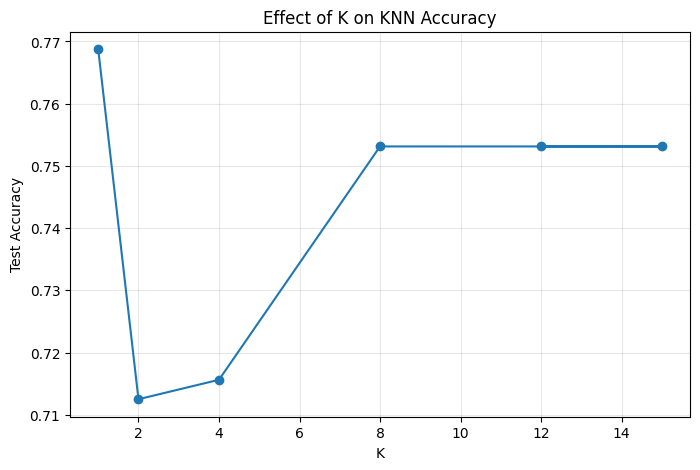

In [ ]:
k_values = [1,2,4,8,15,12]
k_results = []
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, pred)
    k_results.append([k, acc])
k_results_df = pd.DataFrame(k_results, columns=["K", "Accuracy"])
display(k_results_df)
best_row = k_results_df.loc[k_results_df["Accuracy"].idxmax()]
print("Best K on this test split:", int(best_row["K"]))
plt.figure(figsize=(8,5))
plt.plot(k_results_df["K"], k_results_df["Accuracy"], marker="o")
plt.xlabel("K")
plt.ylabel("Test Accuracy")
plt.title("Effect of K on KNN Accuracy")
plt.grid(True, alpha=0.3)
plt.show()

7.4 Predict a New Wine

In [ ]:
best_k = int(best_row["K"])
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)
new_wine = pd.DataFrame([{
"fixed acidity": 7.4,
"volatile acidity": 0.70,
"citric acid": 0.00,
"residual sugar": 1.9,
"chlorides": 0.076,
"free sulfur dioxide": 11.0,
"total sulfur dioxide": 34.0,
"density": 0.9978,
"pH": 3.51,
"sulphates": 0.56,
"alcohol": 9.4
}])
new_wine_scaled = scaler.transform(new_wine)
prediction = final_knn.predict(new_wine_scaled)[0]
print("Predicted class:", "GOOD WINE" if prediction == 1 else "NOT GOOD WINE")

Predicted class: NOT GOOD WINE


8. Linear Regression on Wine Quality

In [ ]:
X_reg = wine_df.drop(columns=["quality"])
y_reg = wine_df["quality"]
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
X_reg, y_reg, test_size=0.20, random_state=42
)
wine_reg = LinearRegression()
wine_reg.fit(Xr_train, yr_train)
yr_pred = wine_reg.predict(Xr_test)
mae = mean_absolute_error(yr_test, yr_pred)
mse = mean_squared_error(yr_test, yr_pred)
rmse = np.sqrt(mse)
r2 = r2_score(yr_test, yr_pred)
print("MAE :", round(mae,4))
print("MSE :", round(mse,4))
print("RMSE:", round(rmse,4))
print("R2 :", round(r2,4))

MAE : 0.5035
MSE : 0.39
RMSE: 0.6245
R2 : 0.4032


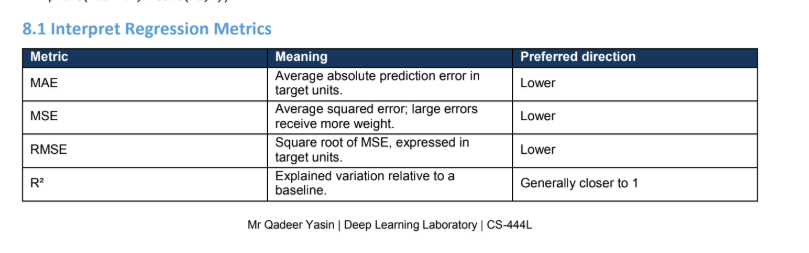

8.1 Interpret Regression Metrics

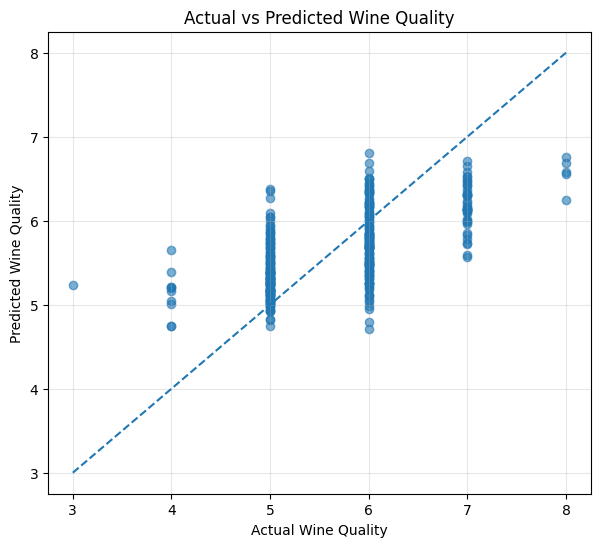

In [ ]:
plt.figure(figsize=(7,6))
plt.scatter(yr_test, yr_pred, alpha=0.6)
minimum = min(yr_test.min(), yr_pred.min())
maximum = max(yr_test.max(), yr_pred.max())
plt.plot([minimum, maximum], [minimum, maximum], linestyle="--")
plt.xlabel("Actual Wine Quality")
plt.ylabel("Predicted Wine Quality")
plt.title("Actual vs Predicted Wine Quality")
plt.grid(True, alpha=0.3)
plt.show()

# Practice with additional dataset : Breast Cancer Wisconsin(Diagnostic)


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
accuracy_score, confusion_matrix, classification_report,
mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.datasets import fetch_california_housing, load_iris, load_diabetes, load_breast_cancer
print("Environment ready.")

Environment ready.


Load and Inspect the Dataset

In [28]:
from sklearn.datasets import load_breast_cancer

# Load the breast cancer dataset
cancer = load_breast_cancer()

# Create a DataFrame
cancer_df = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)
cancer_df['target'] = cancer.target

# Display information
display(cancer_df.head())
print("Shape:", cancer_df.shape)
print("\nData types:")
print(cancer_df.dtypes)
print("\nMissing values:")
print(cancer_df.isnull().sum())
print("\nSummary:")
display(cancer_df.describe())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Shape: (569, 31)

Data types:
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points     

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


6.2 Visualize the Target

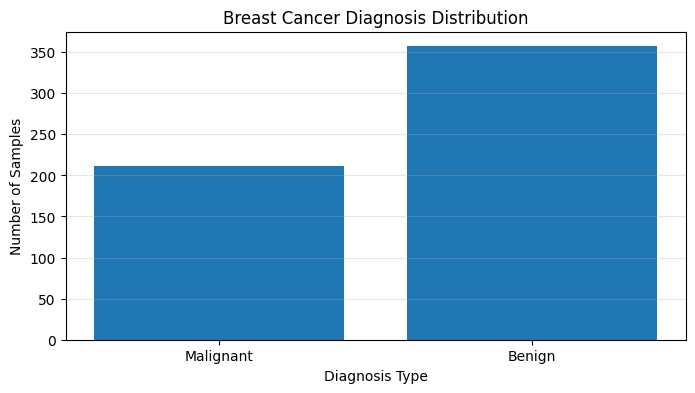

In [29]:
target_counts = cancer_df["target"].value_counts().sort_index()
plt.figure(figsize=(8,4))
plt.bar(target_counts.index, target_counts.values)
plt.xlabel("Diagnosis Type")
plt.ylabel("Number of Samples")
plt.title("Breast Cancer Diagnosis Distribution")
plt.xticks([0, 1], ['Malignant', 'Benign']) # Map 0 to Malignant, 1 to Benign
plt.grid(axis="y", alpha=0.3)
plt.show()

Data Split


In [30]:
X_cancer = cancer_df.drop(columns=["target"])
y_cancer = cancer_df["target"]
X_train, X_test, y_train, y_test = train_test_split(
X_cancer, y_cancer,
test_size=0.20,
random_state=42,
stratify=y_cancer
)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 455
Testing samples: 114


7.2 KNN With Feature Scaling

In [31]:
# Train unscaled KNN for comparison (using the current dataset)
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train, y_train)
y_pred_unscaled = knn_unscaled.predict(X_test)

scaler = StandardScaler()
# Learn scaling parameters from TRAINING data only
X_train_scaled = scaler.fit_transform(X_train)
# Apply the same parameters to TEST data
X_test_scaled = scaler.transform(X_test)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = knn_scaled.predict(X_test_scaled)

print("Unscaled accuracy:", accuracy_score(y_test, y_pred_unscaled))
print("Scaled accuracy: ", accuracy_score(y_test, y_pred_scaled))
print("\nConfusion Matrix (Scaled):")
print(confusion_matrix(y_test, y_pred_scaled))
print("\nClassification Report (Scaled):")
print(classification_report(y_test, y_pred_scaled))

Unscaled accuracy: 0.9122807017543859
Scaled accuracy:  0.956140350877193

Confusion Matrix (Scaled):
[[39  3]
 [ 2 70]]

Classification Report (Scaled):
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



7.3 Predict a New Tumour

In [32]:
final_knn = knn_scaled # Use the previously trained and scaled KNN model

# Create a DataFrame for a new tumor using sample values for all 30 features
# These values are arbitrary for demonstration purposes. In a real scenario,
# these would come from actual patient data.
new_tumor_data = pd.DataFrame([{
    'mean radius': 17.99,
    'mean texture': 10.38,
    'mean perimeter': 122.8,
    'mean area': 1001.0,
    'mean smoothness': 0.1184,
    'mean compactness': 0.2776,
    'mean concavity': 0.3001,
    'mean concave points': 0.1471,
    'mean symmetry': 0.2419,
    'mean fractal dimension': 0.07871,
    'radius error': 1.095,
    'texture error': 0.9053,
    'perimeter error': 8.589,
    'area error': 153.4,
    'smoothness error': 0.006399,
    'compactness error': 0.04904,
    'concavity error': 0.05373,
    'concave points error': 0.01587,
    'symmetry error': 0.03003,
    'fractal dimension error': 0.006193,
    'worst radius': 25.38,
    'worst texture': 17.33,
    'worst perimeter': 184.6,
    'worst area': 2019.0,
    'worst smoothness': 0.1622,
    'worst compactness': 0.6656,
    'worst concavity': 0.7119,
    'worst concave points': 0.2654,
    'worst symmetry': 0.4601,
    'worst fractal dimension': 0.1189
}])

# Scale the new tumor data using the fitted scaler
new_tumor_scaled = scaler.transform(new_tumor_data)

# Predict the class of the new tumor
prediction = final_knn.predict(new_tumor_scaled)[0]

# Map the prediction to human-readable labels
decision = "Benign" if prediction == 1 else "Malignant"
print(f"Predicted diagnosis for the new tumor: {decision}")

Predicted diagnosis for the new tumor: Malignant


# Interpretation

I loaded the Breast Cancer Wisconsin dataset, showing 569 samples with 30 features and a target variable indicating Malignant or Benign(dormant) tumours. KNN Classification with feature scaling was used, which returned a 95.6% accuracy, and a recall of 0.97, which minimizes the negatives for this specific prediction for tumour diagnosis.